# Detecção de fraudes em transações

Autor: Marconi A. D. Silva Filho

[<img src="https://github.githubassets.com/favicons/favicon.svg" width="20"/> GitHub](https://github.com/Marconiadsf)

[<img src="https://static.licdn.com/scds/common/u/images/logos/favicons/v1/favicon.ico" width="20"/> LinkedIn](https://www.linkedin.com/in/marconiabou)

#0.Setup

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#1. EDA

In [ ]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


##1.1 Interpretação do dataset
- Cada linha no dataset representa uma transação financeira: cada registro é uma operação feita por cartão de crédito.

- A coluna Time representa o período desde o início até a coleta de dados (?)

- As colunas V1 até V28 são variáveis transformadas para deanonimização. Não sabemos exatamente o signigficado de cada uma.

- Amount representa o valor da transação.

- Class: Fraudulenta (1) Legítica(0) - a coluna target.



# Problema de classificação desbalanceada

A maioria das transações são legítimas -> modelo pode ignorar a classe com baixa ocorrência.

In [ ]:
 df.Class.value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


# Feature Engineering



In [ ]:
#@title Criar uma nova variável que aplica transformação logarítimica na coluna amount

df["logofAmount"] = np.log1p(df.Amount) # log1p -> evitar problemas com log(0)

### Por que `np.log1p`?

A função `np.log1p(x)` calcula `log(1 + x)`. Ela é especialmente útil quando seus dados podem conter valores que são zero ou muito próximos de zero.

- **Evita o problema de `log(0)`**: O logaritmo de zero é indefinido (tende a menos infinito). Se houver transações com valor `0` na coluna `Amount`, aplicar `np.log(df.Amount)` resultaria em um erro ou em valores `NaN`.
- **Melhora a estabilidade numérica para valores pequenos**: Para valores de `x` muito pequenos, `np.log1p(x)` fornece uma computação mais precisa de `log(1 + x)` do que simplesmente calcular `np.log(1 + x)`, devido a problemas de precisão de ponto flutuante.

Ao usar `np.log1p(df.Amount)`, garantimos que mesmo que `Amount` seja `0`, a operação se torna `log(1 + 0) = log(1) = 0`, evitando erros e mantendo a transformação matematicamente válida.

In [ ]:
#@title NO title yet

scaler = StandardScaler()

df["scaledAmount"] = scaler.fit_transform(df[["Amount"]]) #?? why? muitos modelos sao sensiveis.... mas nao fizemos isso no log1p?

In [ ]:
X = df.drop("Class", axis=1) # features - apenas var de entrada
y = df.Class # target

X_train, X_test, y_train, y_test = train_test_split( X,y,stratify=y, test_size=0.3, random_state=42) #test_size = 30% do data set; stratify: mantem proporção entre as classes.


### Explicação de `train_test_split` (Parâmetros `stratify` e `test_size`)

A função `train_test_split` da biblioteca `sklearn.model_selection` é utilizada para dividir um dataset em conjuntos de treino e teste. Isso é crucial para avaliar o desempenho de um modelo de aprendizado de máquina em dados que ele nunca viu antes.

Os parâmetros importantes usados são:

-   **`test_size=0.3`**: Este parâmetro especifica a proporção do dataset que deve ser alocada para o conjunto de teste. Neste caso, `0.3` (ou 30%) significa que 30% dos dados serão usados para teste e os restantes 70% para treino.

-   **`stratify=y`**: Este é um parâmetro muito importante, especialmente em problemas com classes desbalanceadas (como a detecção de fraudes, onde a classe 'fraude' é muito menos frequente que a classe 'legítima'). Quando `stratify` é definido para a variável `y` (o target ou rótulo da classe):
    -   Garante que a proporção das classes (neste caso, 0s e 1s em `Class`) seja mantida tanto no conjunto de treino quanto no conjunto de teste.
    -   Por exemplo, se a classe 'fraude' representa 0.1% do dataset original, ela também representará aproximadamente 0.1% tanto no `X_train`/`y_train` quanto no `X_test`/`y_test`.
    -   Isso é fundamental para que o modelo seja treinado e avaliado com uma representação realista das classes, evitando que um conjunto de teste tenha pouquíssimos (ou nenhum) exemplo da classe minoritária, o que prejudicaria a avaliação do modelo.

-   **`random_state=42`**: Este parâmetro é usado para inicializar o gerador de números aleatórios. Definir um `random_state` garante que as divisões de treino e teste sejam sempre as mesmas a cada execução do código. Isso torna os resultados reprodutíveis, o que é essencial para depuração e comparação de modelos.

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# accuracy = accuracy_score(y_test, y_pred)
# conf_matrix = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Acurácia pode ser alta mesmo se mdetectar fraldes:
Por isso, nesse caso usamos:
- Recall (mais importante)
- Precision
- F1-score

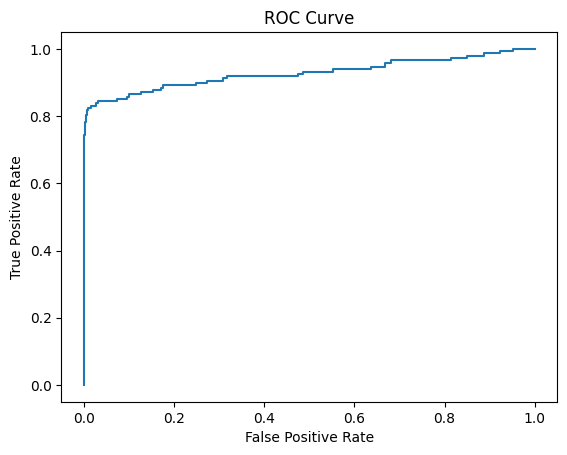

AUC: 0.9272042339543365


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:, 1]  # Probabilidades da classe positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr,tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

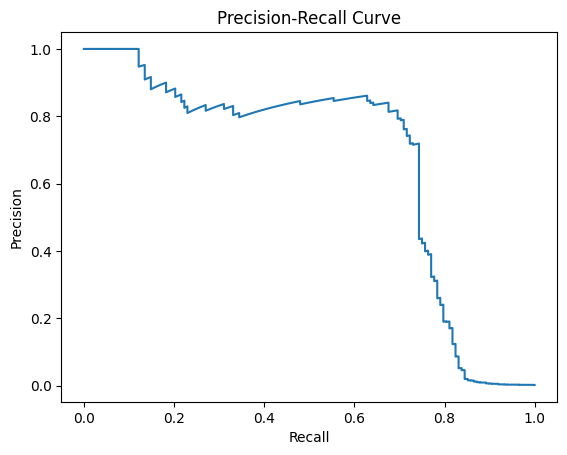

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


# Balanceamento de dados

In [ ]:
#@title Undersampling

fraudes = df[df['Class'] == 1]
normais = df[df['Class'] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])


In [ ]:
#@title Oversampling

from imblearn.over_sampling import SMOTE

smote = SMOTE( #sampling_strategy='auto', random_state=42
            )
X_res, y_res = smote.fit_resample(X, y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier( n_estimators = 50, max_depth=10, class_weight="balanced", n_jobs=-1,random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
#from sklearn.ensemble import RandomForestClassifier
#
#rf = RandomForestClassifier( n_estimators = 50, max_depth=10, class_weight="balanced", n_jobs=-1,random_state=42)
#rf.fit(X_res, y_res)

#y_pred_rf = rf.predict(X_test)

#print(classification_report(y_test, y_pred_rf))

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [ ]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))
#

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.71      0.75       148

    accuracy                           1.00     85443
   macro avg       0.89      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443



# Modelo Avançado - XGBoost

XGBoost é um dos algoritimos mais usados em competições e mercado.

Ele é mais poderoso que Random Forest para muitos problemas.

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,
    use_label_encoder=False,
    eval_metric='logloss',

)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:33:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



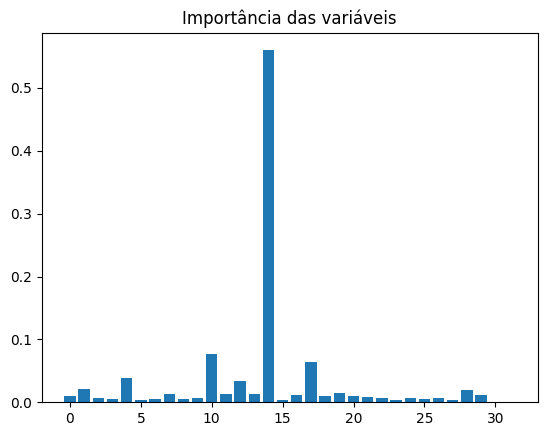

In [ ]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_
plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

# Ajuste de hiperparâmetros


Testar combinações para ajustar o modelo.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    cv=3,
    scoring="recall"
)

grid.fit(X_train, y_train)

print("Melhor modelo: ",grid.best_params_)

Melhor modelo:  {'max_depth': 3, 'n_estimators': 100}


# Explicabilidade (SHAP)

SHAP mostra como cada variável influencia a decisão do modelo.

In [ ]:
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)
shap.plots.bar(shap_values)

NameError: name 'xgb' is not defined